In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [ ]:
from unsloth import FastLanguageModel
import torch



🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model,tokenizer=FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-3-270m-it",
    max_seq_length=2048,
    load_in_4bit=True,
   )

==((====))==  Unsloth 2026.5.9: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


model.safetensors:   0%|          | 0.00/393M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", split = "train[:10000]")
print(len(dataset))        # ~9500 samples
print(dataset.column_names)
print(dataset[0])

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

10000
['text', 'label']
{'text': 'i didnt feel humiliated', 'label': 0}


In [ ]:
!pip install wandb

In [ ]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

In [ ]:
import wandb
wandb.login(key=os.environ["WANDB_API_KEY"])


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gsrishtiksekar (gsrishtiksekar-iiitkottayam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
def convert_to_chatml(examples):
    texts = examples["text"]
    labels = examples["label"]
    conversations = []

    emotion = label_map[labels]
    conversations.append([
            {
                "role": "user",
                "content": f"Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: {texts}"
            },
            {
                "role": "assistant",
                "content": emotion
            }
        ])

    return {"conversations": conversations}

dataset = dataset.map(
    convert_to_chatml
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
def convert_to_chatml1(examples):
    texts = examples["text"]
    labels = examples["label"]
    conversations = []

    emotion = label_map[labels]
    conversations.append([
            {
                "role": "user",
                "content": f"Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: {texts}"
            },
            {
                "role": "assistant",
                "content": emotion
            }
        ])

    return {"conversations": conversations}


In [ ]:
dataset[0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
dataset = dataset.filter(lambda x: x["text"] is not None and isinstance(x["text"], str) and len(x["text"]) > 0)
len(dataset)

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

10000

In [ ]:
test_dataset = load_dataset("dair-ai/emotion", split = "test")

In [ ]:
test_dataset[0]

{'text': 'im feeling rather rotten so im not very ambitious right now',
 'label': 0}

In [ ]:
test_dataset=test_dataset.map(
    convert_to_chatml1
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
test_dataset = test_dataset.filter(lambda x: x["text"] is not None and isinstance(x["text"], str) and len(x["text"]) > 0)
len(test_dataset)

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

2000

In [ ]:
test_dataset[0]

{'text': 'im feeling rather rotten so im not very ambitious right now',
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
dataset[0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
test_dataset=test_dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
dataset[0]

{'text': ['<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n'],
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
test_dataset[0]

{'text': ['<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n'],
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
dataset=dataset.select(range(2000))

In [ ]:
# Check for None or non-string values


In [ ]:
len(dataset)

2000

In [ ]:
print(dataset)
print(dataset.column_names)

print(type(dataset[0]))
print(dataset[0])

for col in dataset.column_names:
    print(col, type(dataset[0][col]))

Dataset({
    features: ['text', 'label', 'conversations'],
    num_rows: 2000
})
['text', 'label', 'conversations']
<class 'dict'>
{'text': ['<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n'], 'label': 0, 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated', 'role': 'user'}, {'content': 'sadness', 'role': 'assistant'}]]}
text <class 'list'>
label <class 'int'>
conversations <class 'list'>


In [ ]:
print(test_dataset)
print(test_dataset.column_names)

print(type(test_dataset[0]))
print(test_dataset[0])

for col in test_dataset.column_names:
    print(col, type(test_dataset[0][col]))

Dataset({
    features: ['text', 'label', 'conversations'],
    num_rows: 2000
})
['text', 'label', 'conversations']
<class 'dict'>
{'text': ['<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n'], 'label': 0, 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now', 'role': 'user'}, {'content': 'sadness', 'role': 'assistant'}]]}
text <class 'list'>
label <class 'int'>
conversations <class 'list'>


In [ ]:
dataset = dataset.map(
    lambda x: {"text": x["text"][0]}
)

print(dataset[0])


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': '<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n', 'label': 0, 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated', 'role': 'user'}, {'content': 'sadness', 'role': 'assistant'}]]}


In [ ]:
test_dataset = test_dataset.map(
    lambda x: {"text": x["text"][0]}
)

print(test_dataset[0])


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': '<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n', 'label': 0, 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: im feeling rather rotten so im not very ambitious right now', 'role': 'user'}, {'content': 'sadness', 'role': 'assistant'}]]}


In [ ]:
print(dataset[0]["text"])
print(type(dataset[0]["text"]))

print(dataset[0]["text"][0])
print(type(dataset[0]["text"][0]))

<bos><start_of_turn>user
Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.

Text: i didnt feel humiliated<end_of_turn>
<start_of_turn>model
sadness<end_of_turn>

<class 'str'>
<
<class 'str'>


In [ ]:
print(test_dataset[0]["text"])
print(type(test_dataset[0]["text"]))

print(test_dataset[0]["text"][0])
print(type(test_dataset[0]["text"][0]))

<bos><start_of_turn>user
Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.

Text: im feeling rather rotten so im not very ambitious right now<end_of_turn>
<start_of_turn>model
sadness<end_of_turn>

<class 'str'>
<
<class 'str'>


In [ ]:
dataset[0]

{'text': '<bos><start_of_turn>user\nClassify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated<end_of_turn>\n<start_of_turn>model\nsadness<end_of_turn>\n',
 'label': 0,
 'conversations': [[{'content': 'Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.\n\nText: i didnt feel humiliated',
    'role': 'user'},
   {'content': 'sadness', 'role': 'assistant'}]]}

In [ ]:
len(test_dataset)

2000

In [ ]:
test_dataset=test_dataset.select(range(100))

In [ ]:
from trl import SFTTrainer, SFTConfig
import torch
import matplotlib.pyplot as plt
from unsloth import FastLanguageModel
import wandb

def train_adapter(dataset, output_dir):
    wandb.init(
        project="gemma-dair-ai-finetuned",
        name=output_dir,
        config={
            "model": "gemma-3-270m-it",
            "r": 8,
            "lora_alpha": 16,
            "max_steps": 500,
            "learning_rate": 2e-4,
            "batch_size": 2,
            "gradient_accumulation_steps": 4,
            "warmup_steps": 5,
            "weight_decay": 0.001,
            "lr_scheduler": "linear",
            "max_seq_length": 1024,
        }
    )

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-3-270m-it",
        max_seq_length=1024,
        load_in_4bit=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=8,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=16,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        eval_dataset=test_dataset,
        args=SFTConfig(
            dataset_text_field="text",
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            warmup_steps=5,
            max_steps=500,
            learning_rate=2e-4,
            logging_steps=5,
            optim="adamw_8bit",
            weight_decay=0.001,
            lr_scheduler_type="linear",
            seed=3407,
            report_to="wandb",       # changed from "none"
            padding_free=False,
            output_dir=output_dir,
            save_strategy="steps",
            save_steps=100,
            save_total_limit=5,
            eval_strategy="steps",
            eval_steps=20,
            max_grad_norm=1.0,
            logging_nan_inf_filter=False,
        )
    )

    trainer.train()

    # Extract logs
    log_history = trainer.state.log_history

    steps      = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
    losses     = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
    grad_steps = [e["step"] for e in log_history if "grad_norm" in e]
    grad_norms = [e["grad_norm"] for e in log_history if "grad_norm" in e]
    eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(steps, losses, color="steelblue", label="Train Loss")
    if eval_losses:
        ax1.plot(eval_steps, eval_losses, color="red",
                 linestyle="--", marker="o", label="Eval Loss")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Training Curves — {output_dir}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(grad_steps, grad_norms, color="darkorange")
    ax2.set_ylabel("Gradient Norm")
    ax2.set_xlabel("Steps")
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{output_dir}_curves.png")
    wandb.log({"training_curves": wandb.Image(f"{output_dir}_curves.png")})
    plt.show()
    wandb.finish()

    model.save_pretrained(output_dir)
    model.push_to_hub(f"Srishtik/{output_dir}", token=os.environ["hf_token"])
    tokenizer.push_to_hub(f"Srishtik/{output_dir}", token=os.environ["hf_token"])
    return model

In [ ]:
print(dataset[0]['text'])

<bos><start_of_turn>user
Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.

Text: i didnt feel humiliated<end_of_turn>
<start_of_turn>model
sadness<end_of_turn>



In [ ]:
print(test_dataset[0]['text'])

<bos><start_of_turn>user
Classify the emotion in this text into one of: sadness, joy, love, anger, fear, surprise.

Text: im feeling rather rotten so im not very ambitious right now<end_of_turn>
<start_of_turn>model
sadness<end_of_turn>



wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260601_071546-tbee7g0u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run gemma_adapter_unsloth_dair_ai_finetuned_500
wandb: ⭐️ View project at https://wandb.ai/gsrishtiksekar-iiitkottayam/gemma-dair-ai-finetuned
wandb: 🚀 View run at https://wandb.ai/gsrishtiksekar-iiitkottayam/gemma-dair-ai-finetuned/runs/tbee7g0u
wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


==((====))==  Unsloth 2026.5.9: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/2000 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 2 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 1,898,496 of 269,996,672 (0.70% trained)


Step,Training Loss,Validation Loss
20,2.172069,1.932505
40,1.991447,1.807709
60,1.626129,1.547632
80,1.692768,1.552206
100,1.507023,1.524440
120,1.530621,1.533437
140,1.897802,1.536032
160,1.800703,1.515041
180,1.675163,1.494430
200,1.486641,1.492037


Unsloth: Restored added_tokens_decoder metadata in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-100/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-100.
Unsloth: Restored added_tokens_decoder metadata in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-200/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-200.
Unsloth: Restored added_tokens_decoder metadata in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-300/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-300.
Unsloth: Restored added_tokens_decoder metadata in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-400/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-400.
Unsloth: Restored added_tokens_decoder metadata in gemma_adapter_unsloth_dair_ai_finetuned_500/checkpoint-500/tokenizer_c

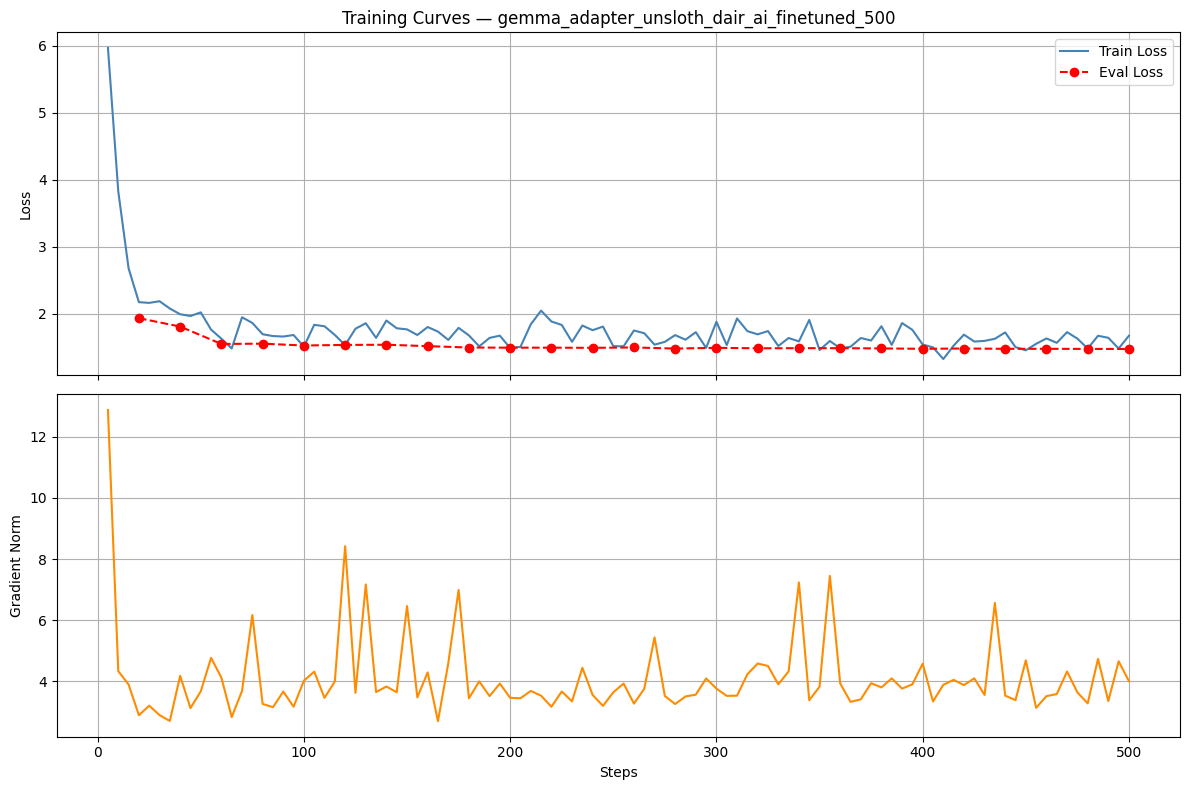

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:               eval/loss █▆▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            eval/runtime █▁▁▁▁▁▁▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁
wandb: eval/samples_per_second ▁▇▇▇▇▇▇▆▆██▇██▇▆▇▇▇▇▇▇▇▆▇
wandb:   eval/steps_per_second ▁▇▇▇▇▇▇▆▆██▇██▇▆▇▇▇▇▇▇▇▆▇
wandb:             train/epoch ▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇████
wandb:       train/global_step ▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
wandb:         train/grad_norm ▁▁▂▄▃▂▆▂▂▃▂█▂▂▃▂▂▂▂▃▂▃▂▃▃█▃▂▂▃▂▃▃▂▂▂▃▂▄▄
wandb:     train/learning_rate █████▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁
wandb:              train/loss █▅▃▂▂▁▁▁▂▂▁▂▂▁▁▂▂▂▂▁▁▁▁▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:               eval/loss 1.47296
wandb:            eval/runtime 6.1376
wandb: eval/samples_per_second 16.293
wandb:   eval/steps_per_second 4.073
wandb:              total_flos 161695461897216.0
wandb:             train/epoch 2
wandb:       train/global_step 500
wandb:         train/grad_norm 4.00306
wandb:     train/le

README.md:   0%|          | 0.00/582 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Srishtik/gemma_adapter_unsloth_dair_ai_finetuned_500


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpta_2uto1/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /tmp/tmpta_2uto1.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [ ]:
model=train_adapter(dataset,"gemma_adapter_unsloth_dair_ai_finetuned_500")